# 05 — EDA segmentado: modalidad, entidad y territorio

**Objetivo especifico que responde:** OE-04 (`InformesRev/AnteproyectoAndres.md`, RF-05: "segmentaciones por modalidad/entidad/territorio") y modulo de indicadores de la seccion 14 de `InformesRev/RESUMEN_CONTROL.md`.

**Insumo:** `analitica-descriptiva-andres/data/indicadores_restriccion_hierro.parquet` (notebook 03).

In [1]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import Image, display

pd.set_option('display.max_columns', 50)
sns.set_style("whitegrid")

REPO = Path(".").resolve().parents[1] if Path(".").resolve().name == "notebooks" else Path(".").resolve()
DATA_DIR = REPO / "analitica-descriptiva-andres" / "data"
FIG_DIR = REPO / "analitica-descriptiva-andres" / "figuras"

df = pd.read_parquet(DATA_DIR / "indicadores_restriccion_hierro.parquet")
print("Indicadores cargados:", df.shape)

def winsorizar(serie, p_bajo=0.01, p_alto=0.99):
    s = serie.dropna()
    lo, hi = s.quantile(p_bajo), s.quantile(p_alto)
    return s.clip(lo, hi)


Indicadores cargados: (19194, 28)


## 1. Segmentacion por modalidad de contratacion

In [2]:
tabla_modalidad = df.groupby('modalidad_de_contratacion').agg(
    n_contratos=('id_contrato', 'count'),
    mediana_desv_tiempo=('desviacion_tiempo_dias', 'median'),
    mediana_desv_costo=('desviacion_costo_pct', 'median'),
).sort_values('n_contratos', ascending=False)
tabla_modalidad


,n_contratos,mediana_desv_tiempo,mediana_desv_costo
modalidad_de_contratacion,,,
Selección Abreviada de Menor Cuantía,6026,1.0,-1.631326e-07
Licitación pública Obra Publica,3947,50.0,-2.242728e+00
Mínima cuantía,3865,0.0,0.000000e+00
Contratación directa,3178,6.0,0.000000e+00
Contratación régimen especial,844,0.0,0.000000e+00
Contratación Directa (con ofertas),636,0.0,-5.984179e-01
Contratación régimen especial (con ofertas),442,3.0,-7.692769e-02
Seleccion Abreviada Menor Cuantia Sin Manifestacion Interes,134,39.5,-2.714798e-01
Licitación pública,122,3.0,-1.000079e+01


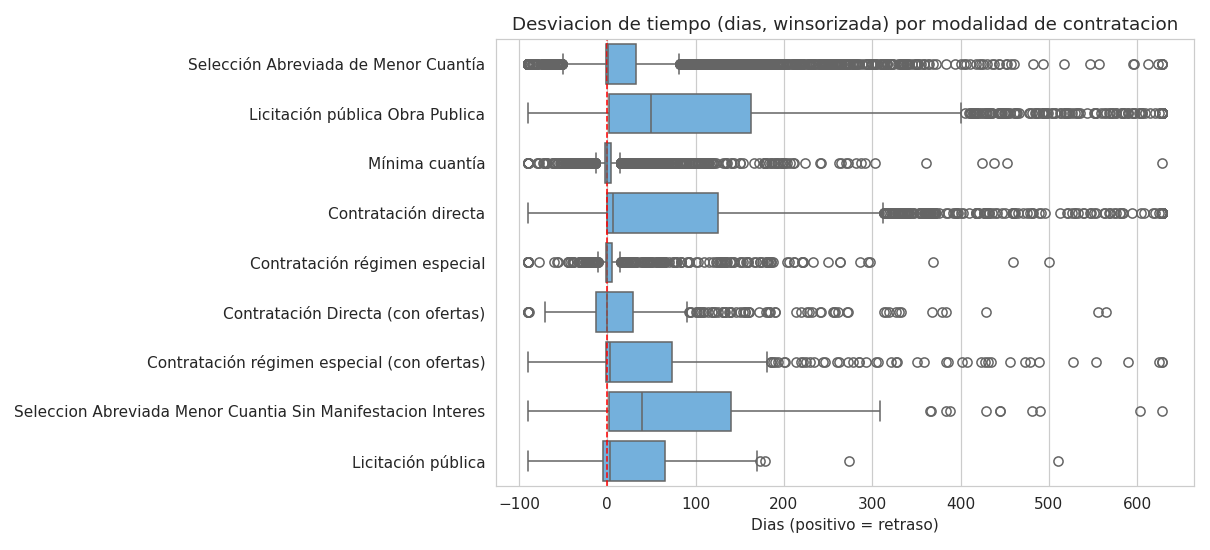

In [3]:
fig, ax = plt.subplots(figsize=(11, 5))
datos_plot = df.copy()
datos_plot['desv_tiempo_wins'] = winsorizar(datos_plot['desviacion_tiempo_dias'])
orden_modalidad = tabla_modalidad.index.tolist()
sns.boxplot(data=datos_plot, y='modalidad_de_contratacion', x='desv_tiempo_wins', order=orden_modalidad, ax=ax, color="#63b3ed")
ax.axvline(0, color="red", linestyle="--", linewidth=1)
ax.set_title("Desviacion de tiempo (dias, winsorizada) por modalidad de contratacion")
ax.set_xlabel("Dias (positivo = retraso)")
ax.set_ylabel("")
plt.tight_layout()
ruta = FIG_DIR / "05_tiempo_por_modalidad.png"
plt.savefig(ruta, dpi=110)
plt.close(fig)
display(Image(filename=str(ruta)))


## 2. Segmentacion por tipo de contratista

In [4]:
tabla_contratista = df.groupby('tipo_contratista').agg(
    n_contratos=('id_contrato', 'count'),
    mediana_desv_tiempo=('desviacion_tiempo_dias', 'median'),
    mediana_desv_costo=('desviacion_costo_pct', 'median'),
    pct_no_entregado=('indice_alcance', lambda s: (s == 'No entregado').mean() * 100),
).sort_values('n_contratos', ascending=False)
tabla_contratista


,n_contratos,mediana_desv_tiempo,mediana_desv_costo,pct_no_entregado
tipo_contratista,,,,
Persona Juridica,11919,1.0,0.000000,26.445172
Consorcio / Union Temporal,4562,27.0,-0.280844,12.384919
Persona Natural,2596,0.0,0.000000,22.072419
No definido,117,0.0,0.000000,28.205128


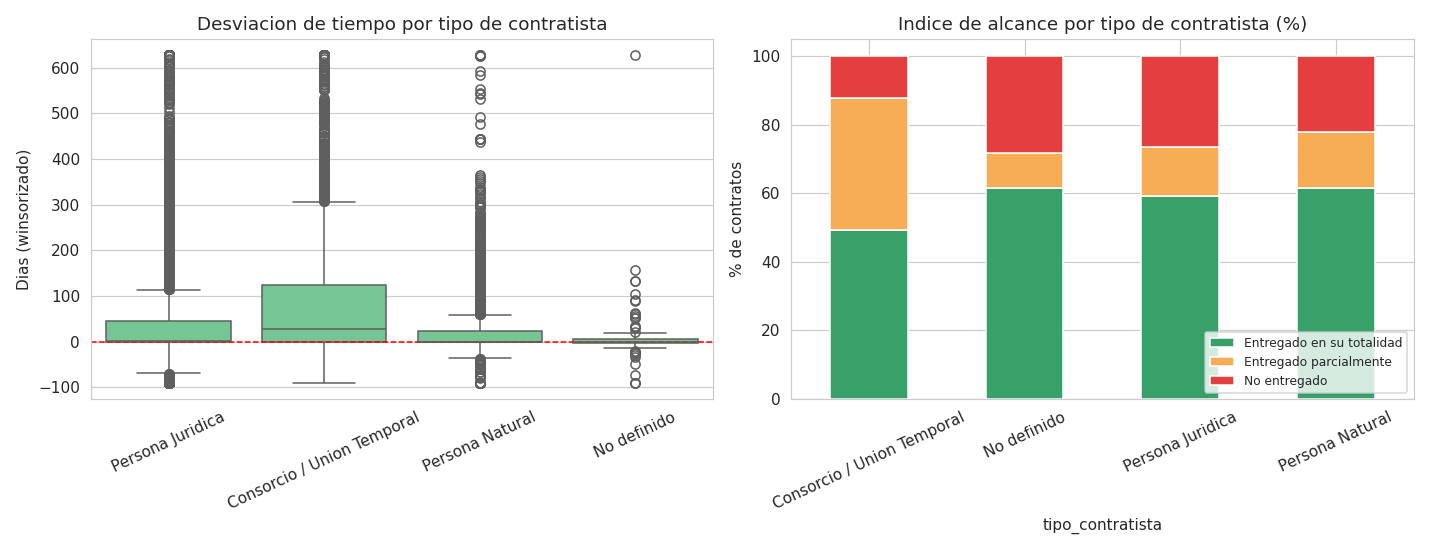

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(data=datos_plot, x='tipo_contratista', y='desv_tiempo_wins', ax=axes[0], color="#68d391")
axes[0].axhline(0, color="red", linestyle="--", linewidth=1)
axes[0].set_title("Desviacion de tiempo por tipo de contratista")
axes[0].set_ylabel("Dias (winsorizado)")
axes[0].set_xlabel("")
axes[0].tick_params(axis='x', rotation=25)

conteo_alcance_contratista = pd.crosstab(df['tipo_contratista'], df['indice_alcance'], normalize='index') * 100
conteo_alcance_contratista = conteo_alcance_contratista[['Entregado en su totalidad', 'Entregado parcialmente', 'No entregado']]
conteo_alcance_contratista.plot(kind='bar', stacked=True, ax=axes[1], color=["#38a169", "#f6ad55", "#e53e3e"])
axes[1].set_title("Indice de alcance por tipo de contratista (%)")
axes[1].set_ylabel("% de contratos")
axes[1].legend(title="", fontsize=8, loc='lower right')
axes[1].tick_params(axis='x', rotation=25)

plt.tight_layout()
ruta = FIG_DIR / "05_segmentado_tipo_contratista.png"
plt.savefig(ruta, dpi=110)
plt.close(fig)
display(Image(filename=str(ruta)))


## 3. Segmentacion por nivel territorial (orden) y departamento

In [6]:
tabla_orden = df.groupby('orden').agg(
    n_contratos=('id_contrato', 'count'),
    mediana_desv_tiempo=('desviacion_tiempo_dias', 'median'),
    mediana_desv_costo=('desviacion_costo_pct', 'median'),
).sort_values('n_contratos', ascending=False)
print(tabla_orden)
print()

top_deptos = df['departamento'].value_counts().head(10).index.tolist()
tabla_depto = (
    df[df['departamento'].isin(top_deptos)]
    .groupby('departamento')
    .agg(n_contratos=('id_contrato', 'count'), mediana_desv_tiempo=('desviacion_tiempo_dias', 'median'))
    .reindex(top_deptos)
)
tabla_depto


                      n_contratos  mediana_desv_tiempo  mediana_desv_costo
orden                                                                     
Territorial                 10781                  3.0                 0.0
Nacional                     8094                  1.0                 0.0
Corporación Autónoma          319                  4.0                 0.0



,n_contratos,mediana_desv_tiempo
departamento,,
Distrito Capital de Bogotá,7345,15.0
Antioquia,2062,1.0
Valle del Cauca,919,3.0
Boyacá,841,1.0
Caldas,793,1.0
Cundinamarca,745,1.0
Santander,654,1.0
Norte de Santander,521,1.0
Huila,466,0.0


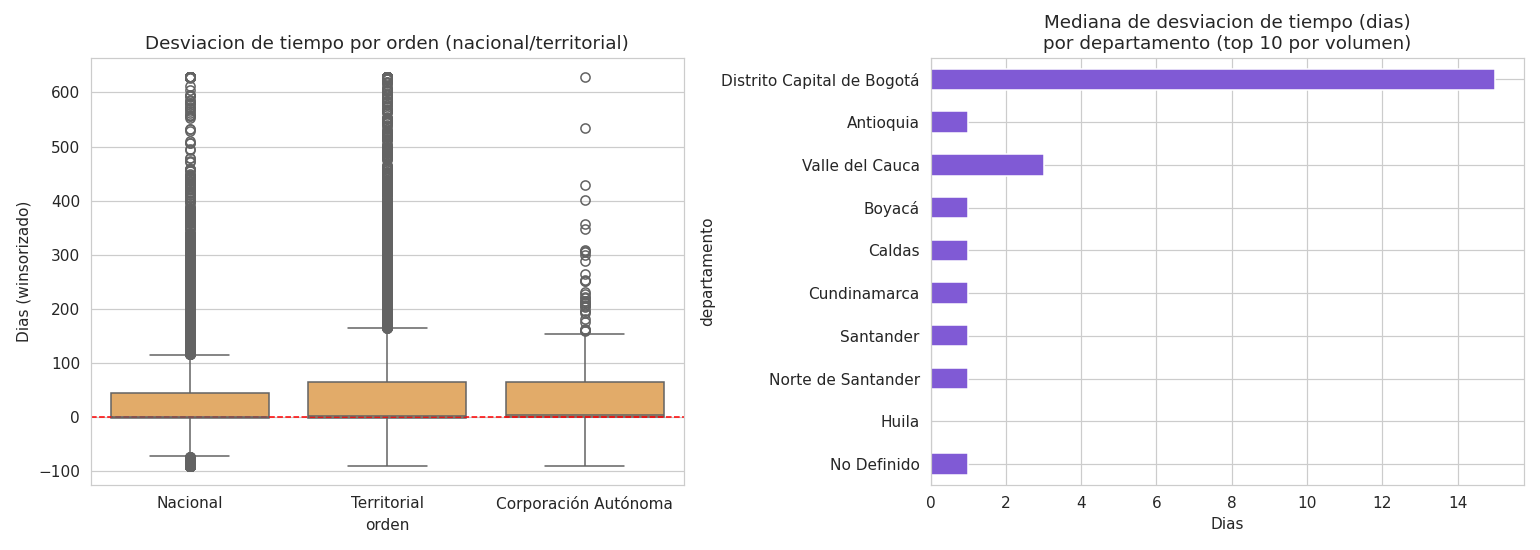

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=datos_plot, x='orden', y='desv_tiempo_wins', ax=axes[0], color="#f6ad55")
axes[0].axhline(0, color="red", linestyle="--", linewidth=1)
axes[0].set_title("Desviacion de tiempo por orden (nacional/territorial)")
axes[0].set_ylabel("Dias (winsorizado)")

tabla_depto['mediana_desv_tiempo'].plot(kind='barh', ax=axes[1], color="#805ad5")
axes[1].invert_yaxis()
axes[1].set_title("Mediana de desviacion de tiempo (dias)\npor departamento (top 10 por volumen)")
axes[1].set_xlabel("Dias")
axes[1].axvline(0, color="red", linestyle="--", linewidth=1)

plt.tight_layout()
ruta = FIG_DIR / "05_segmentado_territorio.png"
plt.savefig(ruta, dpi=110)
plt.close(fig)
display(Image(filename=str(ruta)))


## 4. Sintesis de hallazgos de este notebook

- **Hallazgo contraintuitivo respecto a H1:** la modalidad "Licitacion publica Obra Publica" (mecanismo de mayor competencia) presenta la mediana de desviacion de tiempo mas alta del grupo (50 dias), muy por encima de "Seleccion Abreviada de Menor Cuantia" (1 dia), "Minima cuantia" (0 dias) y "Contratacion directa" (6 dias). Esto va en **sentido contrario** a lo que anticipa H1 (que la mayor competencia se asocia a menores desviaciones). Se contrasta formalmente con prueba estadistica en el notebook 07; de sostenerse, es un hallazgo con valor de discusion importante para la tesis (posible asociacion entre la complejidad/tamaño de los proyectos licitados publicamente y mayores plazos de ejecucion, no necesariamente por menor competencia).
- **Hallazgo mixto respecto a H2:** los consorcios/uniones temporales muestran una mediana de desviacion de tiempo notablemente mayor (27 dias) que personas juridicas individuales (1 dia) y personas naturales (0 dias) — consistente con H2. Sin embargo, la tasa de "No entregado" (terminacion anticipada) es **menor** en consorcios (12.4%) que en personas juridicas (26.4%), un resultado mixto que matiza la hipotesis: los consorcios tienden a demorarse mas, pero no necesariamente a dejar el contrato sin terminar. Ambos patrones se contrastan formalmente en el notebook 07.
- Las entidades de orden Territorial presentan una mediana de desviacion de tiempo levemente mayor (3 dias) que las de orden Nacional (1 dia).
- El departamento con mayor volumen de contratacion de obra (Bogota D.C., 7.345 contratos en la muestra) tambien presenta la mediana de desviacion de tiempo mas alta entre los departamentos de mayor volumen (15 dias, frente a valores de 0-3 dias en el resto) — hallazgo relevante para la hipotesis H3 (aunque H3 se refiere a NBI, no directamente a volumen; ver limitacion de datos de NBI en el notebook 07).
- Todas las tablas y figuras de este notebook alimentan directamente el contenido del futuro tablero interactivo (OE-04) y el capitulo de resultados de la tesis.